<a href="https://colab.research.google.com/github/aaronkharpuri/Student-performance-Analysis/blob/main/Student_Performance_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Data Collection and Setup**

**Environment Setup**

In [2]:
# Install & import everything we need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import urllib.request
import zipfile
import os

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

print('All libraries loaded ✅')

All libraries loaded ✅


**Data Loading**

**Dataset : Student Performance Data (UCI Machine Learning Repository)**

In [3]:
df = pd.read_csv('student-mat.csv', sep=';')
print(f'Dataset loaded ✅  —  {df.shape[0]} rows, {df.shape[1]} columns')
df.head()

Dataset loaded ✅  —  395 rows, 33 columns


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


**Understand variables (grades, attendance, demographics)**

In [4]:
# Check data types and missing values
print('=== Missing Values ===')
print(df.isnull().sum().sum(), 'missing values found')

print('\n=== Data Types ===')
print(df.dtypes)

=== Missing Values ===
0 missing values found

=== Data Types ===
school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences       int64
G1             int64
G2             int64
G3             int64
dtype: object


In [5]:
# Quick look at the final grade distribution
print('=== Final Grade (G3) Summary ===')
print(df['G3'].describe().round(2))

print(f"\nStudents who scored 0: {(df['G3'] == 0).sum()}")

=== Final Grade (G3) Summary ===
count    395.00
mean      10.42
std        4.58
min        0.00
25%        8.00
50%       11.00
75%       14.00
max       20.00
Name: G3, dtype: float64

Students who scored 0: 38


**Initial Target Variable Analysis**

**Visualize the target variable (Final Grade G3)**

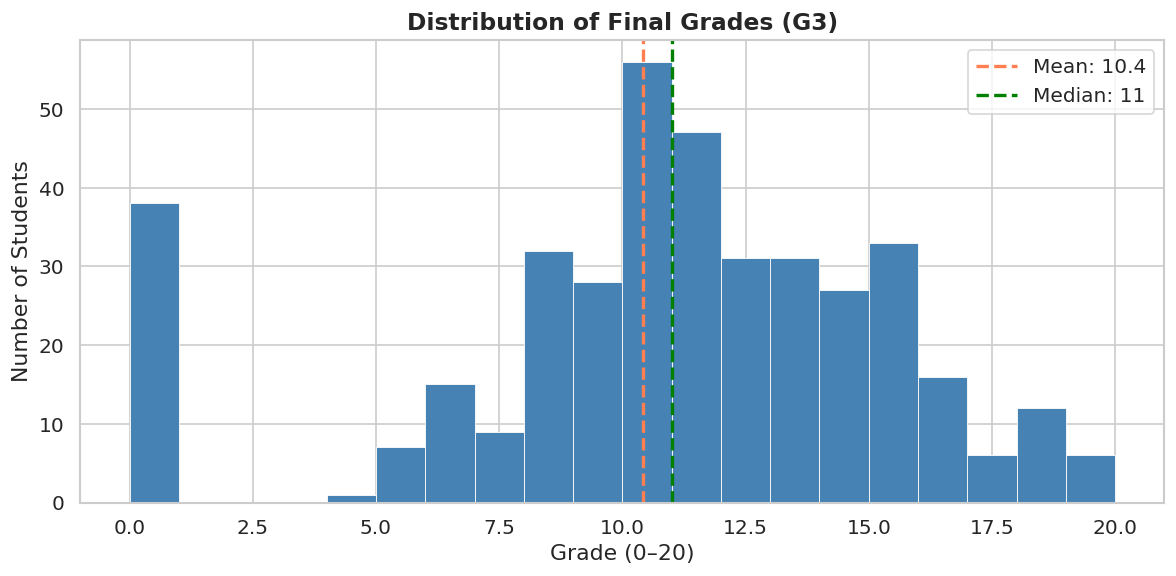

In [6]:
plt.figure(figsize=(10, 5))

plt.hist(df['G3'], bins=20, color='steelblue', edgecolor='white', linewidth=0.5)
plt.axvline(df['G3'].mean(), color='coral', linestyle='--', linewidth=2, label=f"Mean: {df['G3'].mean():.1f}")
plt.axvline(df['G3'].median(), color='green', linestyle='--', linewidth=2, label=f"Median: {df['G3'].median():.0f}")

plt.title('Distribution of Final Grades (G3)', fontsize=14, fontweight='bold')
plt.xlabel('Grade (0–20)')
plt.ylabel('Number of Students')
plt.legend()
plt.tight_layout()
plt.show()

**Exploratory Data Analysis**

**Data Cleaning**

In [7]:
# Remove students who scored 0 (likely dropouts, not genuine scores)
df_clean = df[df['G3'] > 0].copy()

print(f'Original dataset:  {df.shape[0]} students')
print(f'After removing 0s: {df_clean.shape[0]} students')
print(f'Removed:           {df.shape[0] - df_clean.shape[0]} students')

Original dataset:  395 students
After removing 0s: 357 students
Removed:           38 students


**Correlation Analysis**

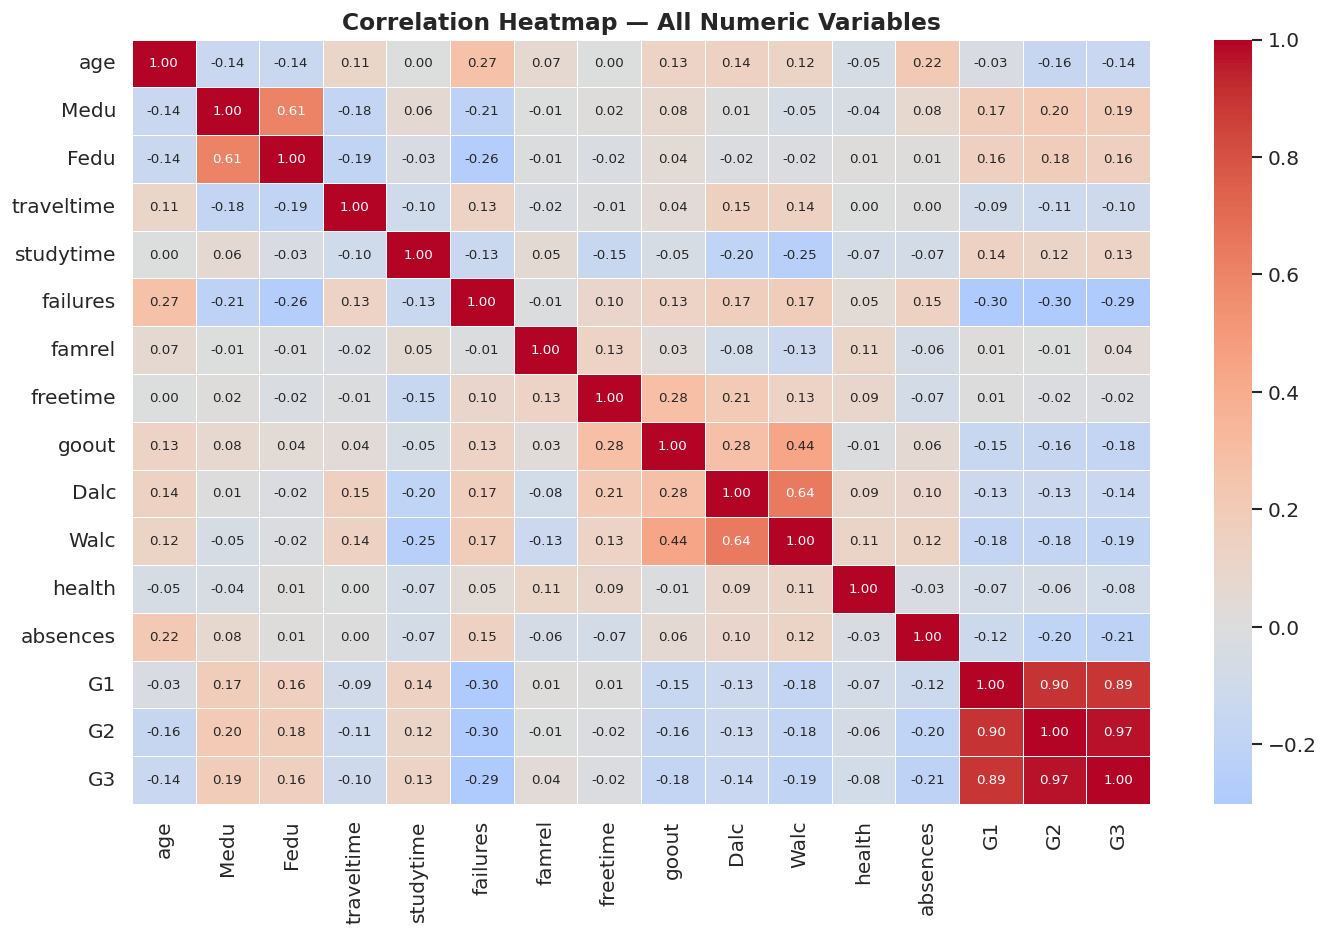

In [8]:
# Correlation heatmap of all numeric columns
plt.figure(figsize=(12, 8))

numeric_df = df_clean.select_dtypes(include='int64')
corr = numeric_df.corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 8})

plt.title('Correlation Heatmap — All Numeric Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Key Numeric Variables Analysis**

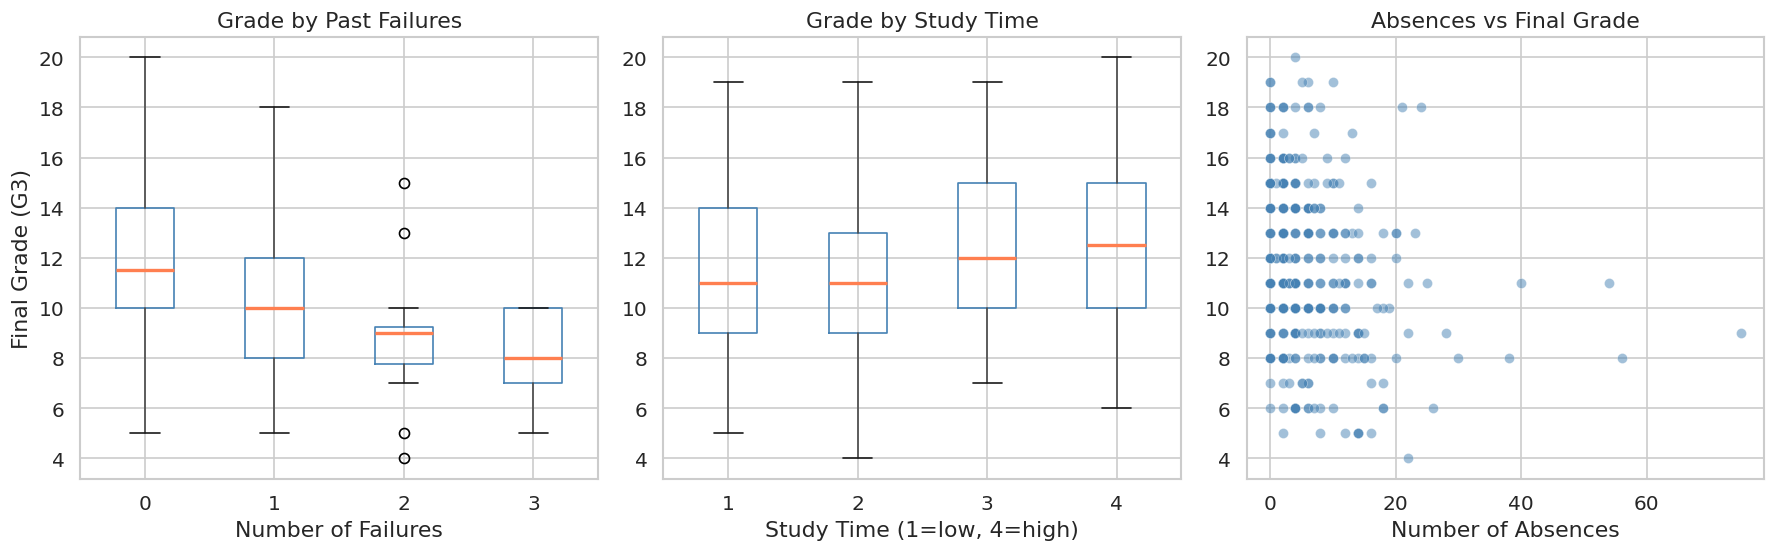

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Failures vs G3
df_clean.boxplot(column='G3', by='failures', ax=axes[0],
                 boxprops=dict(color='steelblue'),
                 medianprops=dict(color='coral', linewidth=2))
axes[0].set_title('Grade by Past Failures')
axes[0].set_xlabel('Number of Failures')
axes[0].set_ylabel('Final Grade (G3)')
plt.sca(axes[0]); plt.title('Grade by Past Failures')

# Study time vs G3
df_clean.boxplot(column='G3', by='studytime', ax=axes[1],
                 boxprops=dict(color='steelblue'),
                 medianprops=dict(color='coral', linewidth=2))
axes[1].set_title('Grade by Study Time')
axes[1].set_xlabel('Study Time (1=low, 4=high)')
axes[1].set_ylabel('')
plt.sca(axes[1]); plt.title('Grade by Study Time')

# Absences vs G3
axes[2].scatter(df_clean['absences'], df_clean['G3'],
                alpha=0.5, color='steelblue', edgecolors='white', linewidth=0.3)
axes[2].set_title('Absences vs Final Grade')
axes[2].set_xlabel('Number of Absences')
axes[2].set_ylabel('')

plt.suptitle('')
plt.tight_layout()
plt.show()

**Categorical Variables Analysis**

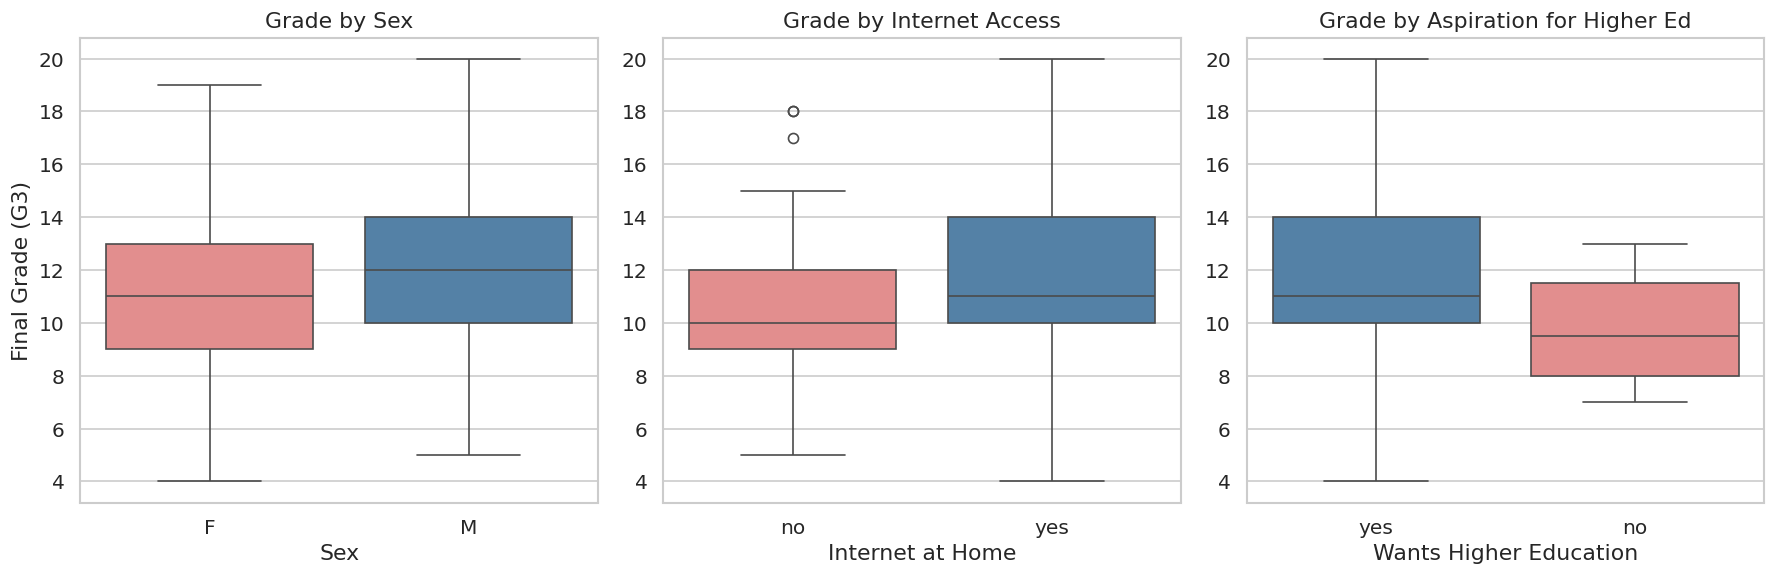

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Grade by sex
sns.boxplot(data=df_clean, x='sex', y='G3', ax=axes[0],
            hue='sex', palette={'F': 'lightcoral', 'M': 'steelblue'}, legend=False)
axes[0].set_title('Grade by Sex')
axes[0].set_xlabel('Sex')
axes[0].set_ylabel('Final Grade (G3)')

# Grade by internet access
sns.boxplot(data=df_clean, x='internet', y='G3', ax=axes[1],
            hue='internet', palette={'yes': 'steelblue', 'no': 'lightcoral'}, legend=False)
axes[1].set_title('Grade by Internet Access')
axes[1].set_xlabel('Internet at Home')
axes[1].set_ylabel('')

# Grade by higher education aspiration
sns.boxplot(data=df_clean, x='higher', y='G3', ax=axes[2],
            hue='higher', palette={'yes': 'steelblue', 'no': 'lightcoral'}, legend=False)
axes[2].set_title('Grade by Aspiration for Higher Ed')
axes[2].set_xlabel('Wants Higher Education')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()

**Lifestyle Factors Analysis**

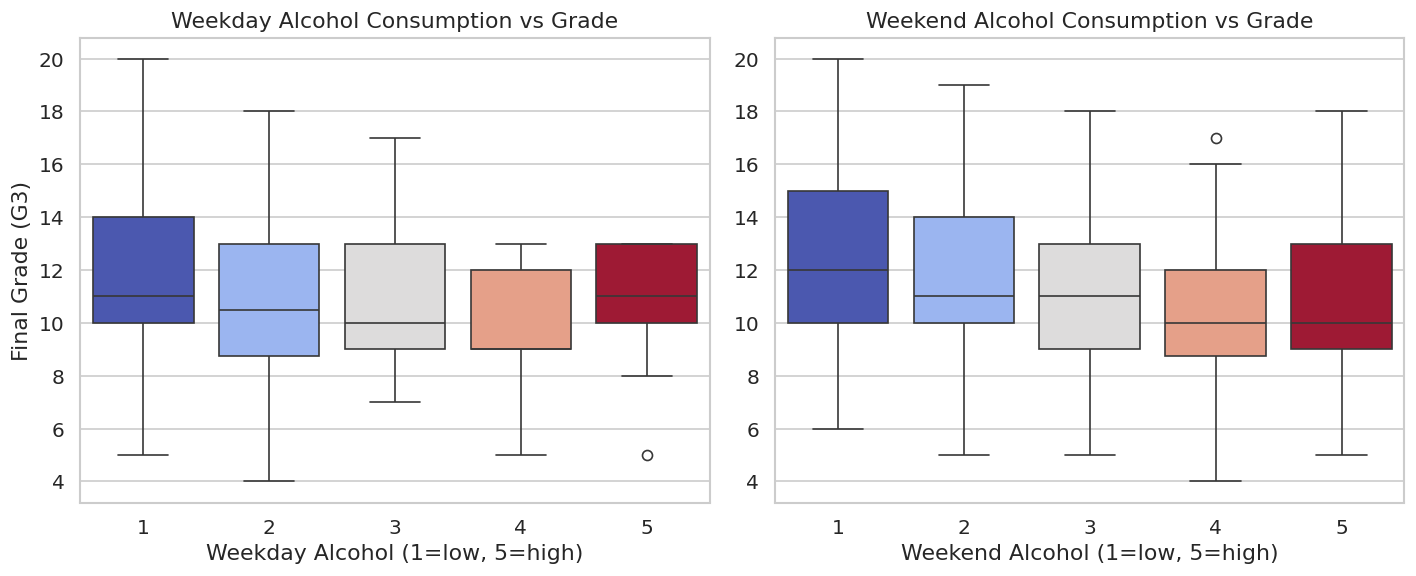

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Weekday alcohol vs G3
sns.boxplot(data=df_clean, x='Dalc', y='G3', ax=axes[0],
            hue='Dalc', palette='coolwarm', legend=False)
axes[0].set_title('Weekday Alcohol Consumption vs Grade')
axes[0].set_xlabel('Weekday Alcohol (1=low, 5=high)')
axes[0].set_ylabel('Final Grade (G3)')

# Weekend alcohol vs G3
sns.boxplot(data=df_clean, x='Walc', y='G3', ax=axes[1],
            hue='Walc', palette='coolwarm', legend=False)
axes[1].set_title('Weekend Alcohol Consumption vs Grade')
axes[1].set_xlabel('Weekend Alcohol (1=low, 5=high)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

**Feature Engineering and Analysis**

**Target Variable Engineering**

In [12]:
# Create a pass/fail column (passing grade is 10 or above out of 20)
df_clean['pass_fail'] = df_clean['G3'].apply(lambda x: 'Pass' if x >= 10 else 'Fail')

# Check the split
print('=== Pass/Fail Distribution ===')
print(df_clean['pass_fail'].value_counts())
print(f"\nPass rate: {(df_clean['pass_fail'] == 'Pass').mean() * 100:.1f}%")

=== Pass/Fail Distribution ===
pass_fail
Pass    265
Fail     92
Name: count, dtype: int64

Pass rate: 74.2%


**Derived Feature Creation**

In [13]:
# Create additional features
df_clean['alcohol_avg'] = (df_clean['Dalc'] + df_clean['Walc']) / 2
df_clean['parent_edu_avg'] = (df_clean['Medu'] + df_clean['Fedu']) / 2
df_clean['grade_improvement'] = df_clean['G3'] - df_clean['G1']

print('=== New Features Created ===')
print(f"Average alcohol score:      {df_clean['alcohol_avg'].mean():.2f}")
print(f"Average parent education:   {df_clean['parent_edu_avg'].mean():.2f}")
print(f"Average grade improvement:  {df_clean['grade_improvement'].mean():.2f}")

=== New Features Created ===
Average alcohol score:      1.91
Average parent education:   2.67
Average grade improvement:  0.25


**Statistical Significance Testing**

In [22]:
from scipy import stats

print('=== Hypothesis Tests ===\n')

# Test 1: Do students who want higher education score significantly higher?
higher_yes = df_clean[df_clean['higher'] == 'yes']['G3']
higher_no  = df_clean[df_clean['higher'] == 'no']['G3']
t1, p1 = stats.ttest_ind(higher_yes, higher_no)
print(f"1. Higher education aspiration vs G3")
print(f"   Mean (yes): {higher_yes.mean():.2f} | Mean (no): {higher_no.mean():.2f}")
print(f"   t={t1:.2f}, p={p1:.4f} → {'SIGNIFICANT' if p1 < 0.05 else 'Not significant'}\n")

# Test 2: Does internet access significantly affect grades?
internet_yes = df_clean[df_clean['internet'] == 'yes']['G3']
internet_no  = df_clean[df_clean['internet'] == 'no']['G3']
t2, p2 = stats.ttest_ind(internet_yes, internet_no)
print(f"2. Internet access vs G3")
print(f"   Mean (yes): {internet_yes.mean():.2f} | Mean (no): {internet_no.mean():.2f}")
print(f"   t={t2:.2f}, p={p2:.4f} → {'SIGNIFICANT' if p2 < 0.05 else 'Not significant'}\n")

# Test 3: Do males and females score significantly differently?
male   = df_clean[df_clean['sex'] == 'M']['G3']
female = df_clean[df_clean['sex'] == 'F']['G3']
t3, p3 = stats.ttest_ind(male, female)
print(f"3. Sex vs G3")
print(f"   Mean (M): {male.mean():.2f} | Mean (F): {female.mean():.2f}")
print(f"   t={t3:.2f}, p={p3:.4f} → {'SIGNIFICANT' if p3 < 0.05 else 'Not significant'}\n")

# Test 4: Does number of failures significantly affect grades?
no_fail   = df_clean[df_clean['failures'] == 0]['G3']
with_fail = df_clean[df_clean['failures'] > 0]['G3']
t4, p4 = stats.ttest_ind(no_fail, with_fail)
print(f"4. Past failures vs G3")
print(f"   Mean (0 failures): {no_fail.mean():.2f} | Mean (1+ failures): {with_fail.mean():.2f}")
print(f"   t={t4:.2f}, p={p4:.4f} → {'SIGNIFICANT' if p4 < 0.05 else 'Not significant'}")

=== Hypothesis Tests ===

1. Higher education aspiration vs G3
   Mean (yes): 11.60 | Mean (no): 9.71
   t=2.15, p=0.0322 → SIGNIFICANT

2. Internet access vs G3
   Mean (yes): 11.68 | Mean (no): 10.71
   t=2.12, p=0.0350 → SIGNIFICANT

3. Sex vs G3
   Mean (M): 11.87 | Mean (F): 11.21
   t=1.94, p=0.0531 → Not significant

4. Past failures vs G3
   Mean (0 failures): 11.94 | Mean (1+ failures): 9.57
   t=5.50, p=0.0000 → SIGNIFICANT


**Hypothesis Testing Visualization**

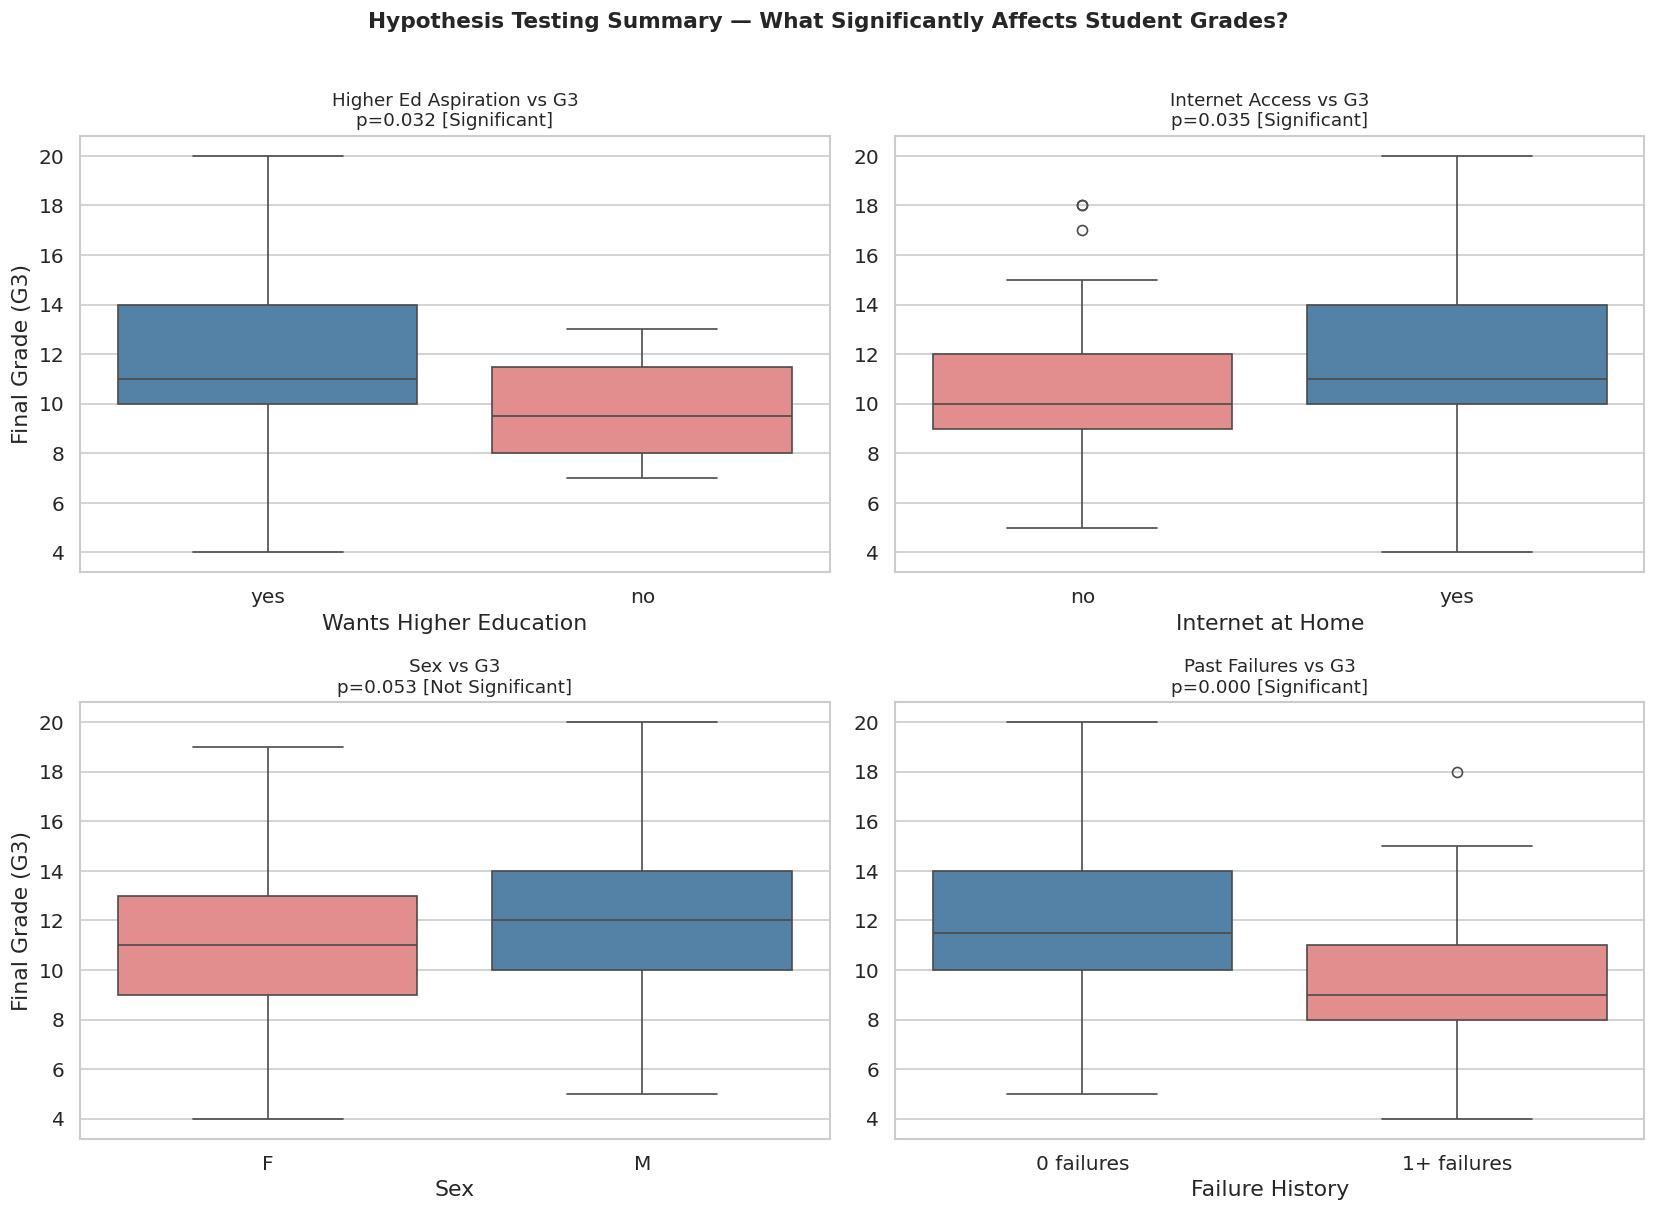

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Higher education
sns.boxplot(data=df_clean, x='higher', y='G3', ax=axes[0,0],
            hue='higher', palette={'yes':'steelblue','no':'lightcoral'}, legend=False)
axes[0,0].set_title('Higher Ed Aspiration vs G3\np=0.032 [Significant]', fontsize=11)
axes[0,0].set_xlabel('Wants Higher Education')
axes[0,0].set_ylabel('Final Grade (G3)')

# 2. Internet access
sns.boxplot(data=df_clean, x='internet', y='G3', ax=axes[0,1],
            hue='internet', palette={'yes':'steelblue','no':'lightcoral'}, legend=False)
axes[0,1].set_title('Internet Access vs G3\np=0.035 [Significant]', fontsize=11)
axes[0,1].set_xlabel('Internet at Home')
axes[0,1].set_ylabel('')

# 3. Sex
sns.boxplot(data=df_clean, x='sex', y='G3', ax=axes[1,0],
            hue='sex', palette={'M':'steelblue','F':'lightcoral'}, legend=False)
axes[1,0].set_title('Sex vs G3\np=0.053 [Not Significant]', fontsize=11)
axes[1,0].set_xlabel('Sex')
axes[1,0].set_ylabel('Final Grade (G3)')

# 4. Past failures
sns.boxplot(data=df_clean,
            x=df_clean['failures'].apply(lambda x: '0 failures' if x == 0 else '1+ failures'),
            y='G3', ax=axes[1,1],
            hue=df_clean['failures'].apply(lambda x: '0 failures' if x == 0 else '1+ failures'),
            palette={'0 failures':'steelblue','1+ failures':'lightcoral'}, legend=False)
axes[1,1].set_title('Past Failures vs G3\np=0.000 [Significant]', fontsize=11)
axes[1,1].set_xlabel('Failure History')
axes[1,1].set_ylabel('')

plt.suptitle('Hypothesis Testing Summary — What Significantly Affects Student Grades?',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Predictive Modelling**

**Model Setup & Library Imports**

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

print('Libraries loaded successfully.')

Libraries loaded successfully.


**Data Preprocessing for Modeling**

In [17]:
# Encode categorical columns as numbers
df_model = df_clean.copy()

cat_cols = ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob',
            'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities',
            'nursery', 'higher', 'internet', 'romantic']

le = LabelEncoder()
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])

# Define features and target
X = df_model.drop(columns=['G1', 'G2', 'G3', 'pass_fail'])
y = df_model['pass_fail'].apply(lambda x: 1 if x == 'Pass' else 0)

# Split into training and test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Data prepared successfully.')
print(f'Training set: {X_train.shape[0]} samples')
print(f'Test set:     {X_test.shape[0]} samples')
print(f'Features:     {X_train.shape[1]}')

Data prepared successfully.
Training set: 285 samples
Test set:     72 samples
Features:     33


**Model Training & Comparison**

In [18]:
# Train three models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'      : DecisionTreeClassifier(random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f'{name}: {acc * 100:.1f}% accuracy')

Logistic Regression: 80.6% accuracy
Decision Tree: 61.1% accuracy
Random Forest: 76.4% accuracy


**Model Evaluation**

=== Classification Report ===
              precision    recall  f1-score   support

        Fail       0.86      0.32      0.46        19
        Pass       0.80      0.98      0.88        53

    accuracy                           0.81        72
   macro avg       0.83      0.65      0.67        72
weighted avg       0.82      0.81      0.77        72

=== Confusion Matrix ===


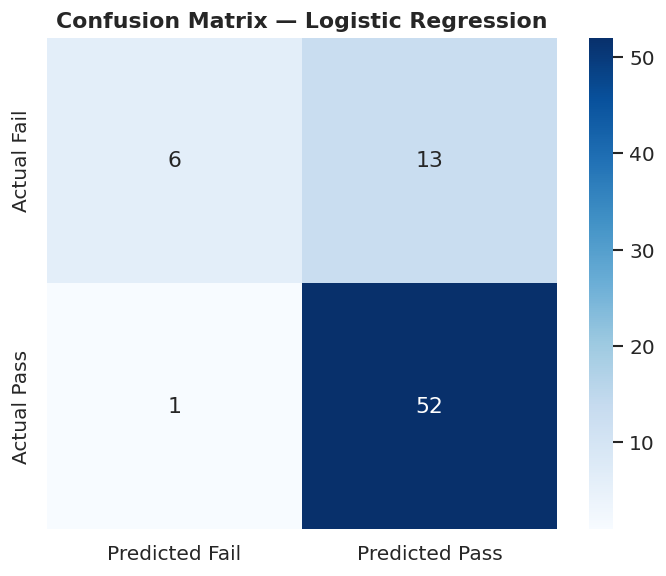

In [19]:
# Detailed evaluation of the best model — Logistic Regression
best_model = models['Logistic Regression']
y_pred = best_model.predict(X_test)

print('=== Classification Report ===')
print(classification_report(y_test, y_pred, target_names=['Fail', 'Pass']))

print('=== Confusion Matrix ===')
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Fail', 'Predicted Pass'],
            yticklabels=['Actual Fail', 'Actual Pass'])
plt.title('Confusion Matrix — Logistic Regression', fontweight='bold')
plt.tight_layout()
plt.show()

**Feature Importance Analysis**

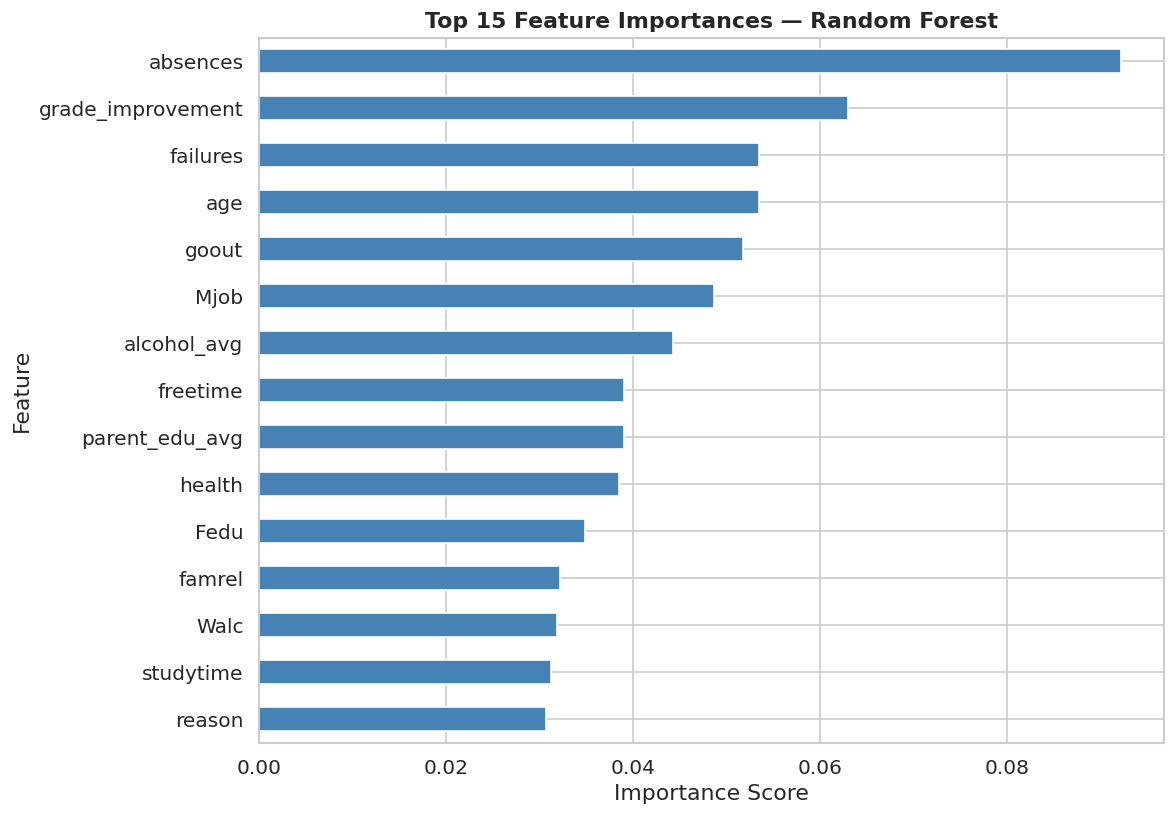

In [20]:
# Feature importance from Random Forest
rf_model = models['Random Forest']
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=True).tail(15)

plt.figure(figsize=(10, 7))
importances.plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Top 15 Feature Importances — Random Forest', fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

**Project Summary & Visualization Dashboard**

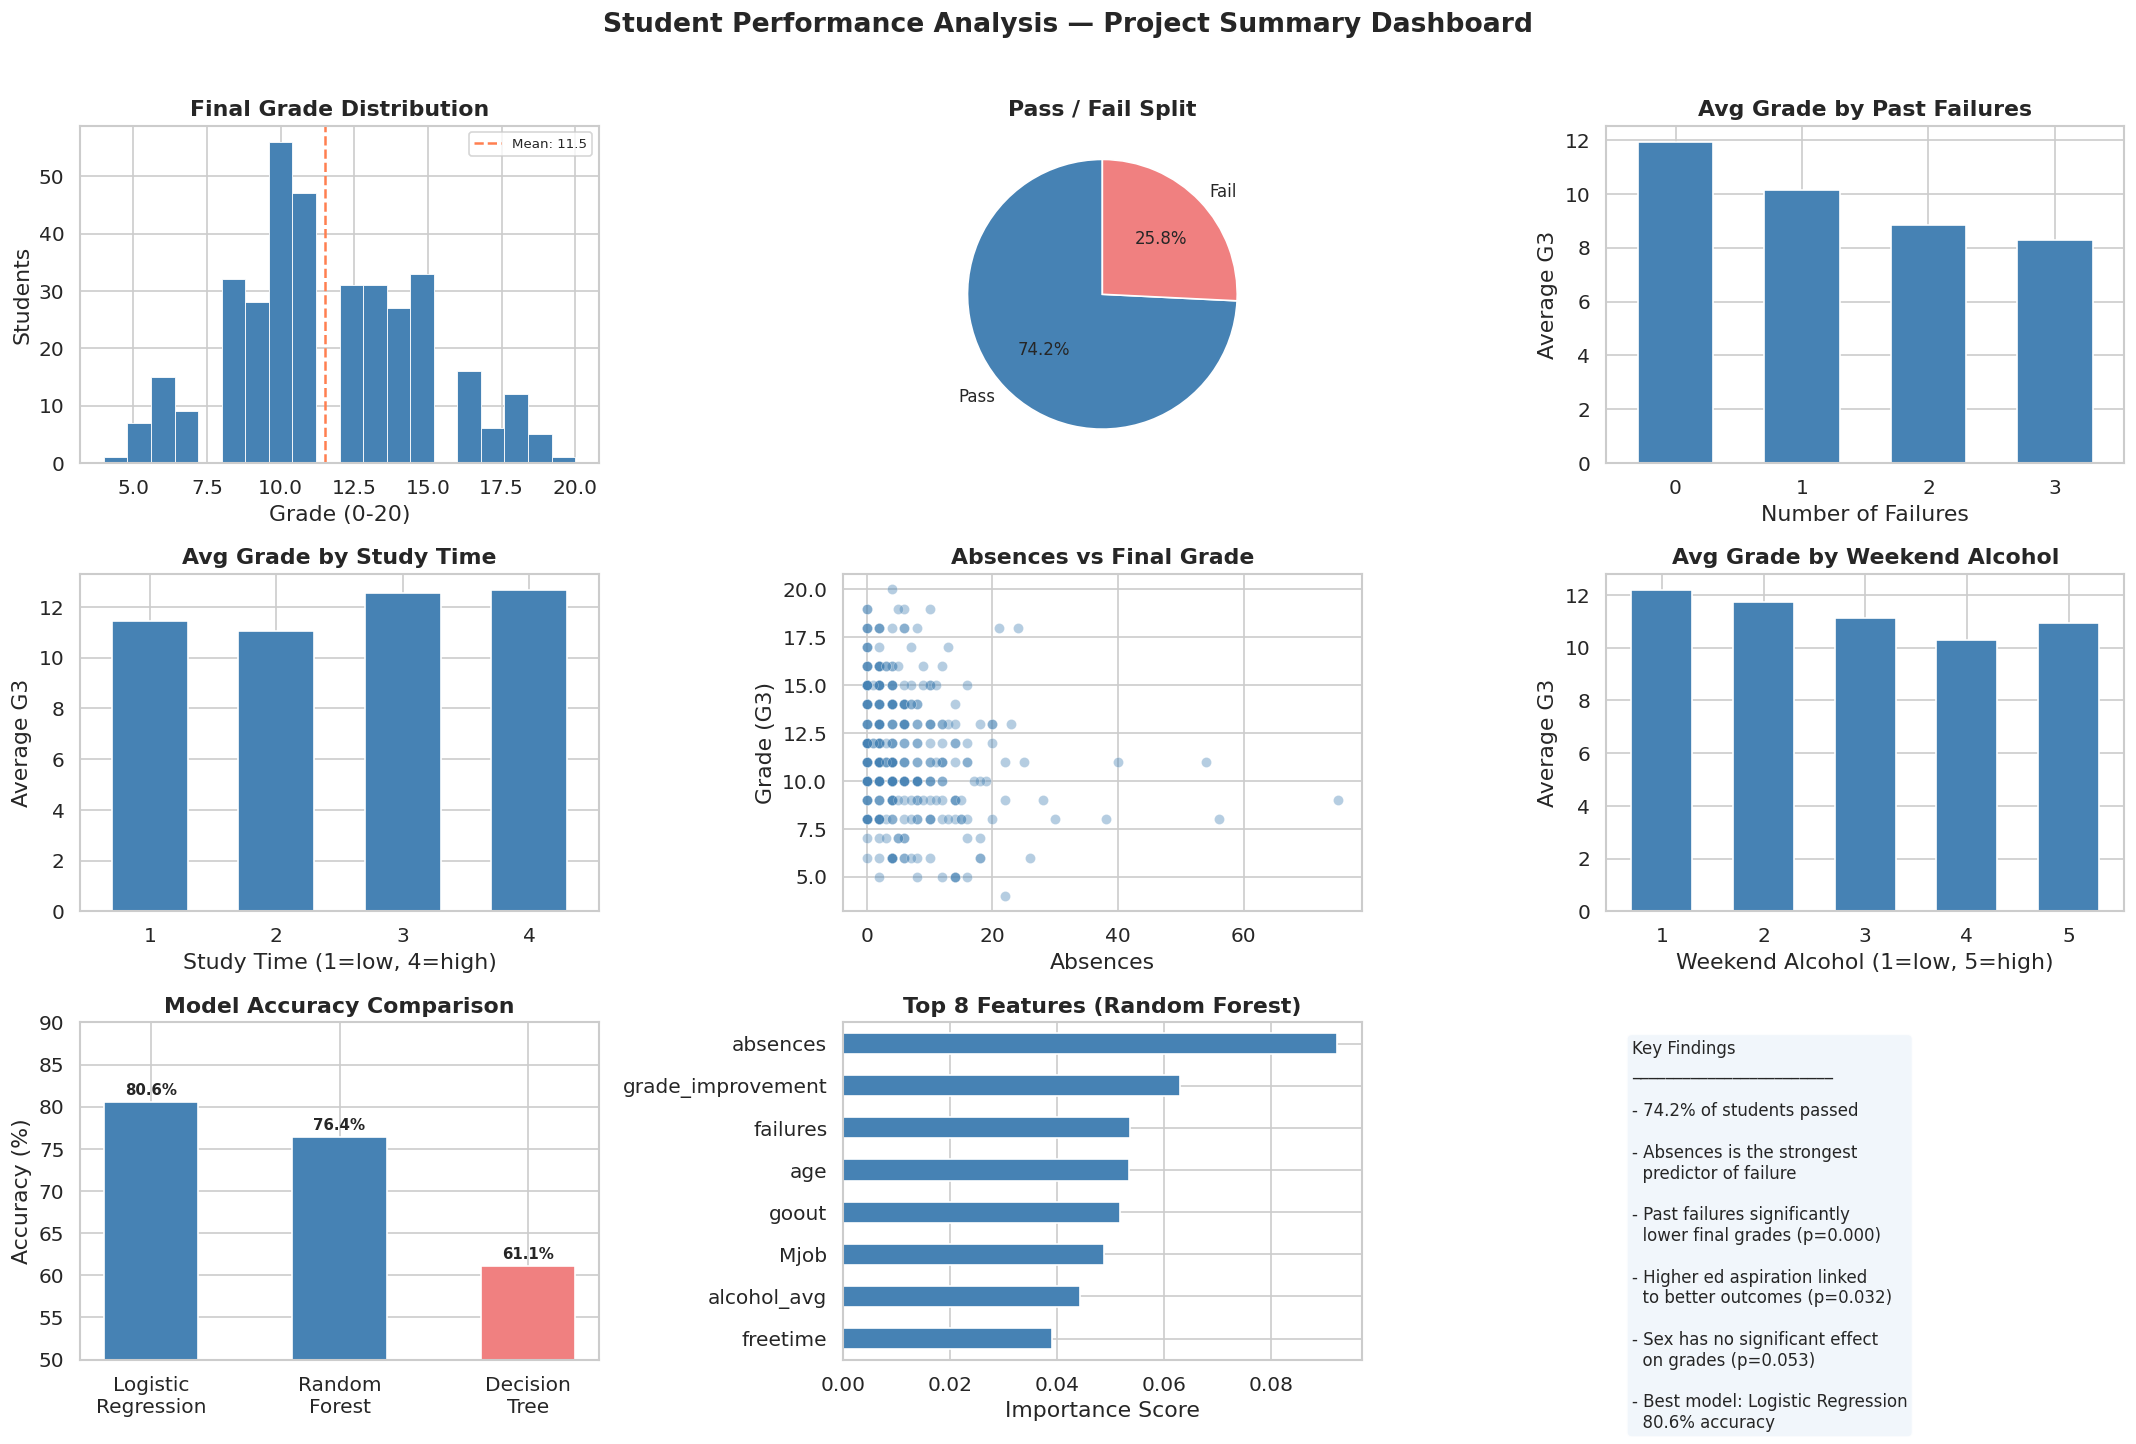

Dashboard saved as student_analysis_dashboard.png


In [21]:
fig = plt.figure(figsize=(18, 12))
fig.suptitle('Student Performance Analysis — Project Summary Dashboard',
             fontsize=16, fontweight='bold', y=1.01)

# 1. Grade distribution
ax1 = fig.add_subplot(3, 3, 1)
ax1.hist(df_clean['G3'], bins=20, color='steelblue', edgecolor='white', linewidth=0.5)
ax1.axvline(df_clean['G3'].mean(), color='coral', linestyle='--', linewidth=1.5,
            label=f"Mean: {df_clean['G3'].mean():.1f}")
ax1.set_title('Final Grade Distribution', fontweight='bold')
ax1.set_xlabel('Grade (0-20)')
ax1.set_ylabel('Students')
ax1.legend(fontsize=8)

# 2. Pass/Fail pie chart
ax2 = fig.add_subplot(3, 3, 2)
counts = df_clean['pass_fail'].value_counts()
ax2.pie(counts, labels=counts.index, autopct='%1.1f%%',
        colors=['steelblue', 'lightcoral'], startangle=90,
        textprops={'fontsize': 10})
ax2.set_title('Pass / Fail Split', fontweight='bold')

# 3. Failures vs Grade
ax3 = fig.add_subplot(3, 3, 3)
df_clean.groupby('failures')['G3'].mean().plot(kind='bar', ax=ax3,
    color='steelblue', edgecolor='white', width=0.6)
ax3.set_title('Avg Grade by Past Failures', fontweight='bold')
ax3.set_xlabel('Number of Failures')
ax3.set_ylabel('Average G3')
ax3.tick_params(axis='x', rotation=0)

# 4. Study time vs Grade
ax4 = fig.add_subplot(3, 3, 4)
df_clean.groupby('studytime')['G3'].mean().plot(kind='bar', ax=ax4,
    color='steelblue', edgecolor='white', width=0.6)
ax4.set_title('Avg Grade by Study Time', fontweight='bold')
ax4.set_xlabel('Study Time (1=low, 4=high)')
ax4.set_ylabel('Average G3')
ax4.tick_params(axis='x', rotation=0)

# 5. Absences vs Grade scatter
ax5 = fig.add_subplot(3, 3, 5)
ax5.scatter(df_clean['absences'], df_clean['G3'],
            alpha=0.4, color='steelblue', edgecolors='white', linewidth=0.3)
ax5.set_title('Absences vs Final Grade', fontweight='bold')
ax5.set_xlabel('Absences')
ax5.set_ylabel('Grade (G3)')

# 6. Alcohol vs Grade
ax6 = fig.add_subplot(3, 3, 6)
df_clean.groupby('Walc')['G3'].mean().plot(kind='bar', ax=ax6,
    color='steelblue', edgecolor='white', width=0.6)
ax6.set_title('Avg Grade by Weekend Alcohol', fontweight='bold')
ax6.set_xlabel('Weekend Alcohol (1=low, 5=high)')
ax6.set_ylabel('Average G3')
ax6.tick_params(axis='x', rotation=0)

# 7. Model accuracy comparison
ax7 = fig.add_subplot(3, 3, 7)
model_names = ['Logistic\nRegression', 'Random\nForest', 'Decision\nTree']
accuracies  = [80.6, 76.4, 61.1]
bars = ax7.bar(model_names, accuracies, color=['steelblue', 'steelblue', 'lightcoral'],
               edgecolor='white', width=0.5)
ax7.set_title('Model Accuracy Comparison', fontweight='bold')
ax7.set_ylabel('Accuracy (%)')
ax7.set_ylim(50, 90)
for bar, acc in zip(bars, accuracies):
    ax7.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{acc}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

# 8. Feature importance (top 8)
ax8 = fig.add_subplot(3, 3, 8)
top8 = importances.tail(8)
top8.plot(kind='barh', ax=ax8, color='steelblue', edgecolor='white')
ax8.set_title('Top 8 Features (Random Forest)', fontweight='bold')
ax8.set_xlabel('Importance Score')

# 9. Key findings text box
ax9 = fig.add_subplot(3, 3, 9)
ax9.axis('off')
findings = (
    "Key Findings\n"
    "________________________\n\n"
    "- 74.2% of students passed\n\n"
    "- Absences is the strongest\n"
    "  predictor of failure\n\n"
    "- Past failures significantly\n"
    "  lower final grades (p=0.000)\n\n"
    "- Higher ed aspiration linked\n"
    "  to better outcomes (p=0.032)\n\n"
    "- Sex has no significant effect\n"
    "  on grades (p=0.053)\n\n"
    "- Best model: Logistic Regression\n"
    "  80.6% accuracy"
)
ax9.text(0.05, 0.95, findings, transform=ax9.transAxes,
         fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='#EEF4FB', alpha=0.8))

plt.tight_layout()
plt.savefig('student_analysis_dashboard.png', bbox_inches='tight', dpi=150)
plt.show()

print('Dashboard saved as student_analysis_dashboard.png')